# Islamabad AQI — Exploratory Data Analysis

This notebook explores the historical air quality dataset used to train the AQI forecasting models in this project.

**Data source:** `data/islamabad_aqicn_historical.csv` (fetched via `src/data/fetch_historical.py` from Open-Meteo's air-quality archive).

**Goals:**
1. Understand the shape, coverage, and quality of the raw data
2. Examine the AQI distribution and how often hazardous levels occur
3. Identify seasonal / daily patterns
4. Check pollutant correlations and lag relationships
5. Summarize findings that inform modeling choices (feature engineering, target horizons, evaluation caveats)

## 1. Setup & Load Data

In [3]:
!pip install pandas numpy matplotlib seaborn

  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp312-cp312-win_amd64.whl.metadata (126 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 1.9 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.8 MB 2.4 MB/s eta 0:00:04
  


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_PATH = "../data/islamabad_aqicn_historical.csv"  # adjust if running from a different working directory

df = pd.read_csv(DATA_PATH, parse_dates=["time"])
df = df.sort_values("time").reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['time'].min()}  \u2192  {df['time'].max()}")
print(f"Span: {(df['time'].max() - df['time'].min()).days} days (~{(df['time'].max() - df['time'].min()).days / 365.25:.1f} years)")
df.head()

Rows: 35,832
Columns: ['time', 'us_aqi', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'carbon_monoxide', 'temperature', 'humidity', 'pressure', 'wind_speed']
Date range: 2022-08-05 00:00:00  →  2026-09-05 23:00:00
Span: 1492 days (~4.1 years)


,time,us_aqi,pm2_5,pm10,nitrogen_dioxide,sulphur_dioxide,ozone,carbon_monoxide,temperature,humidity,pressure,wind_speed
0,2022-08-05 00:00:00,134.0,47.0,67.8,10.3,11.1,113.0,531.0,0.0,0.0,0.0,0.0
1,2022-08-05 01:00:00,134.0,35.7,51.5,12.9,10.6,113.0,521.0,0.0,0.0,0.0,0.0
2,2022-08-05 02:00:00,132.0,22.9,33.1,16.5,9.8,113.0,506.0,0.0,0.0,0.0,0.0
3,2022-08-05 03:00:00,129.0,18.4,26.5,19.3,9.0,116.0,487.0,0.0,0.0,0.0,0.0
4,2022-08-05 04:00:00,126.0,18.7,27.1,17.8,9.2,123.0,478.0,0.0,0.0,0.0,0.0


## 2. Data Quality Check

Confirm there are no unexpected gaps, duplicate timestamps, or missing values before drawing conclusions from the data.

In [5]:
print("Missing values per column:")
print(df.isna().sum())

print(f"\nDuplicate timestamps: {df['time'].duplicated().sum()}")

# Check for gaps in the hourly timeline
expected_range = pd.date_range(df["time"].min(), df["time"].max(), freq="h")
missing_hours = expected_range.difference(df["time"])
print(f"Expected hourly timestamps: {len(expected_range):,}")
print(f"Actual timestamps: {len(df):,}")
print(f"Missing hours: {len(missing_hours):,} ({len(missing_hours) / len(expected_range) * 100:.1f}% of expected range)")

Missing values per column:
time                0
us_aqi              0
pm2_5               0
pm10                0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
carbon_monoxide     0
temperature         0
humidity            0
pressure            0
wind_speed          0
dtype: int64

Duplicate timestamps: 0
Expected hourly timestamps: 35,832
Actual timestamps: 35,832
Missing hours: 0 (0.0% of expected range)


## 3. AQI Distribution

How is `us_aqi` distributed overall, and how often does it fall into each health category?

count    35832.000000
mean       112.333054
std         31.142792
min         14.000000
25%         87.000000
50%        106.000000
75%        137.000000
max        218.000000
Name: us_aqi, dtype: float64


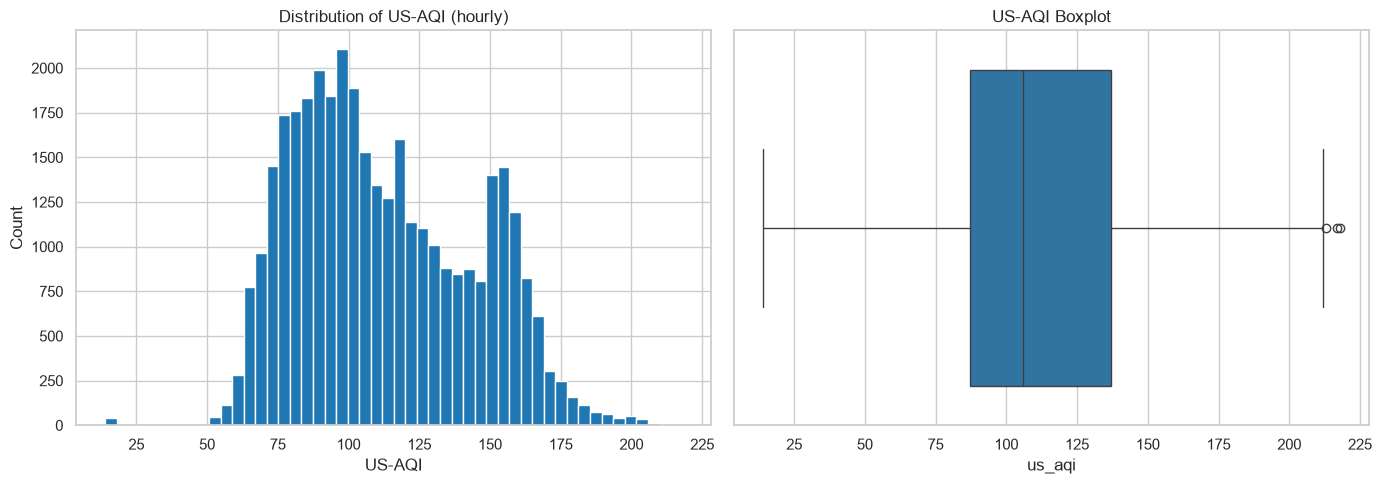

In [6]:
print(df["us_aqi"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["us_aqi"], bins=50, color="#1f77b4", edgecolor="white")
axes[0].set_title("Distribution of US-AQI (hourly)")
axes[0].set_xlabel("US-AQI")
axes[0].set_ylabel("Count")

sns.boxplot(x=df["us_aqi"], ax=axes[1], color="#1f77b4")
axes[1].set_title("US-AQI Boxplot")

plt.tight_layout()
plt.show()

                       count  pct_of_data
aqi_category                             
Good                      48         0.13
Moderate               15361        42.87
Unhealthy (Sensitive)  14355        40.06
Unhealthy               5998        16.74
Very Unhealthy            70         0.20
Hazardous                  0         0.00


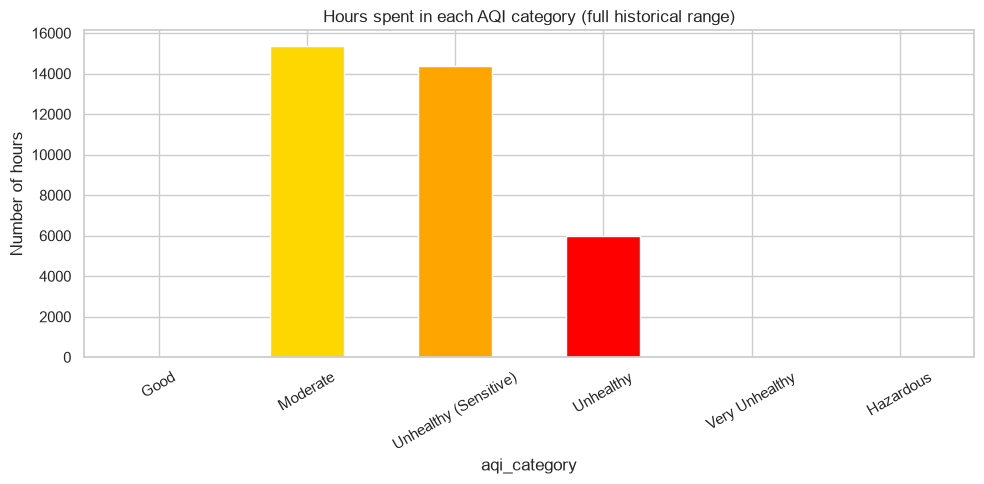


% of time at 'Very Unhealthy' or worse (AQI > 200): 0.20%
% of time at 'Hazardous' (AQI > 300): 0.00%


In [7]:
# AQI category breakdown
bins = [0, 50, 100, 150, 200, 300, float("inf")]
labels = ["Good", "Moderate", "Unhealthy (Sensitive)", "Unhealthy", "Very Unhealthy", "Hazardous"]

df["aqi_category"] = pd.cut(df["us_aqi"], bins=bins, labels=labels)
category_counts = df["aqi_category"].value_counts().reindex(labels)
category_pct = (category_counts / len(df) * 100).round(2)

summary = pd.DataFrame({"count": category_counts, "pct_of_data": category_pct})
print(summary)

plt.figure(figsize=(10, 5))
colors = ["green", "gold", "orange", "red", "purple", "maroon"]
category_counts.plot(kind="bar", color=colors)
plt.title("Hours spent in each AQI category (full historical range)")
plt.ylabel("Number of hours")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"\n% of time at 'Very Unhealthy' or worse (AQI > 200): {(df['us_aqi'] > 200).mean() * 100:.2f}%")
print(f"% of time at 'Hazardous' (AQI > 300): {(df['us_aqi'] > 300).mean() * 100:.2f}%")

**Note:** As found during earlier data collection, Islamabad's AQI in this dataset rarely reaches 'Very Unhealthy' and never reaches 'Hazardous' over the ~4-year window available from Open-Meteo. This is an important caveat for model evaluation — the model has very few examples of extreme AQI to learn from, so predictions in that range should be treated as extrapolation rather than validated forecasts.

## 4. Time Series View

Full history, plus a zoomed-in view of a recent month to see short-term dynamics more clearly.

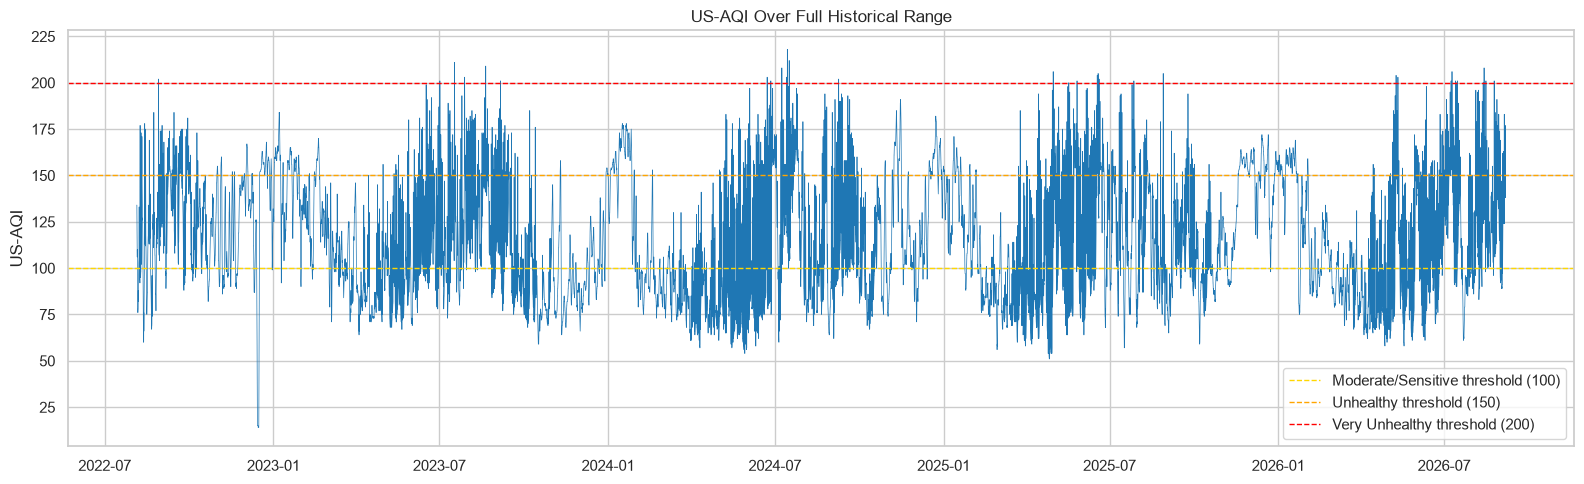

In [8]:
plt.figure(figsize=(16, 5))
plt.plot(df["time"], df["us_aqi"], linewidth=0.5, color="#1f77b4")
plt.axhline(100, color="gold", linestyle="--", linewidth=1, label="Moderate/Sensitive threshold (100)")
plt.axhline(150, color="orange", linestyle="--", linewidth=1, label="Unhealthy threshold (150)")
plt.axhline(200, color="red", linestyle="--", linewidth=1, label="Very Unhealthy threshold (200)")
plt.title("US-AQI Over Full Historical Range")
plt.ylabel("US-AQI")
plt.legend()
plt.tight_layout()
plt.show()

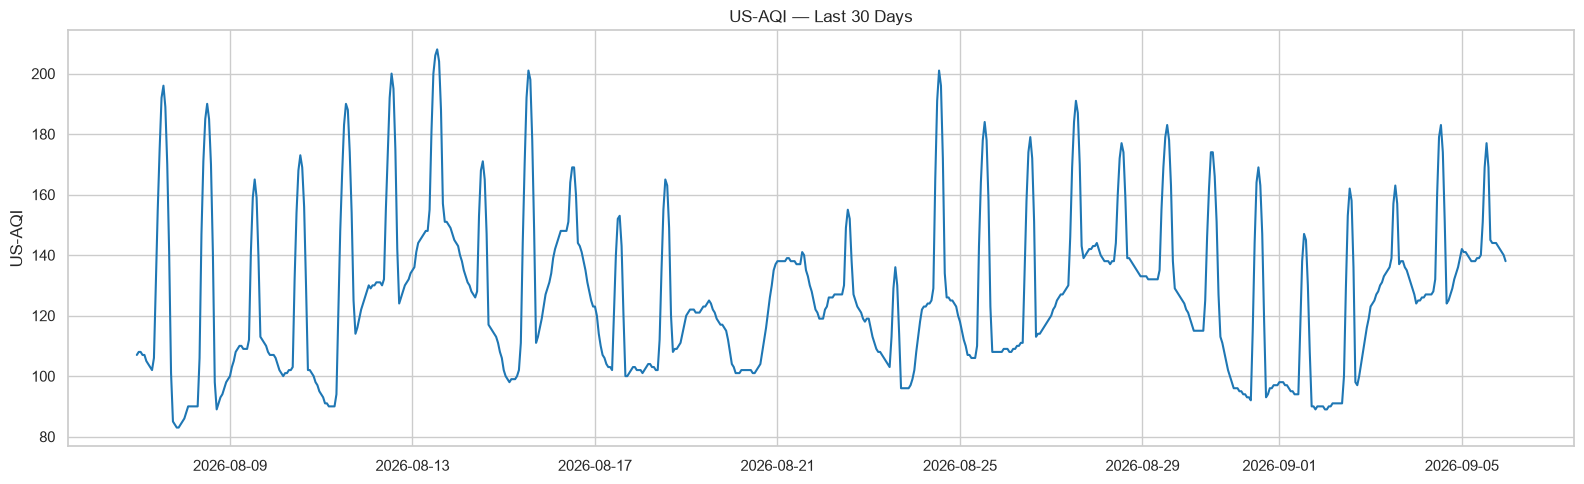

In [9]:
# Zoom into the most recent 30 days for a closer look at short-term dynamics
recent = df[df["time"] >= df["time"].max() - pd.Timedelta(days=30)]

plt.figure(figsize=(16, 5))
plt.plot(recent["time"], recent["us_aqi"], color="#1f77b4")
plt.title("US-AQI — Last 30 Days")
plt.ylabel("US-AQI")
plt.tight_layout()
plt.show()

## 5. Seasonal & Time-of-Day Patterns

Islamabad's AQI is expected to worsen in winter (temperature inversion, crop burning) — check whether that shows up in this dataset, and whether there's a within-day pattern.

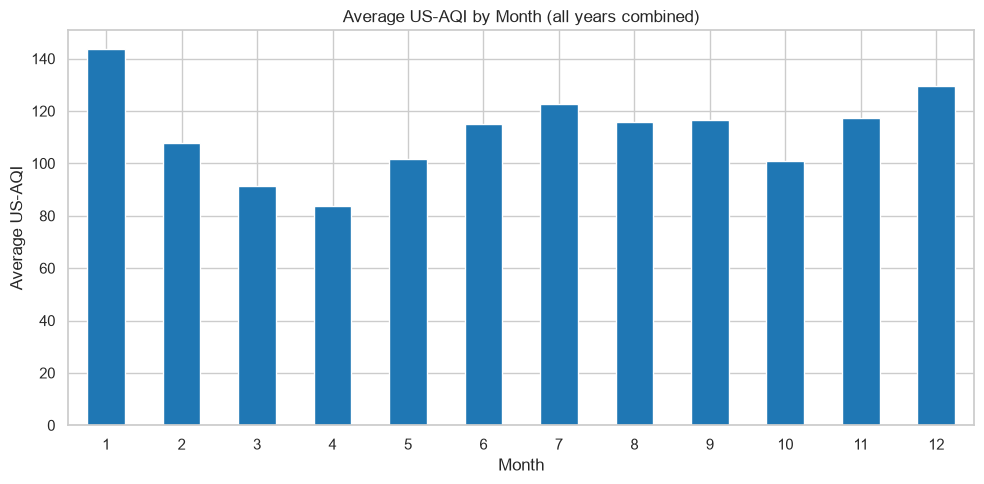

In [10]:
df["month"] = df["time"].dt.month
df["hour"] = df["time"].dt.hour
df["year"] = df["time"].dt.year

monthly_avg = df.groupby("month")["us_aqi"].mean()

plt.figure(figsize=(10, 5))
monthly_avg.plot(kind="bar", color="#1f77b4")
plt.title("Average US-AQI by Month (all years combined)")
plt.xlabel("Month")
plt.ylabel("Average US-AQI")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

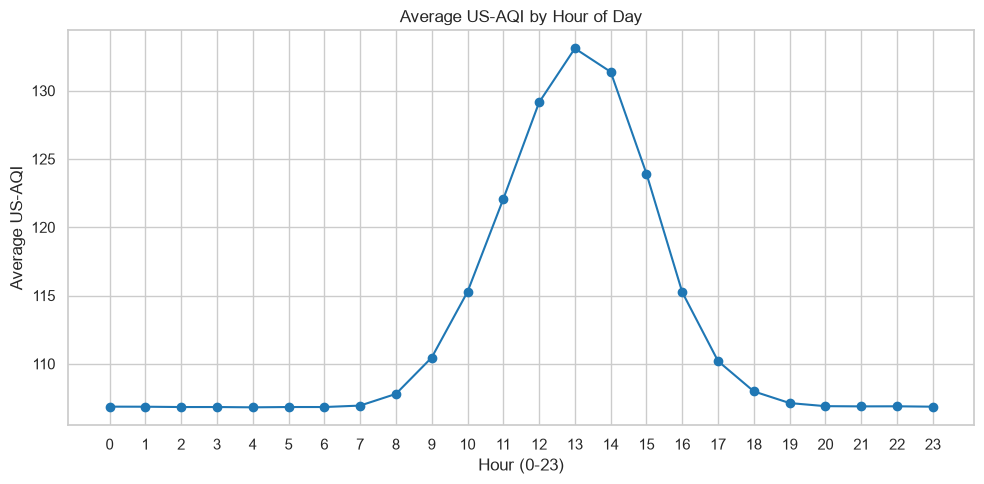

In [11]:
hourly_avg = df.groupby("hour")["us_aqi"].mean()

plt.figure(figsize=(10, 5))
hourly_avg.plot(kind="line", marker="o", color="#1f77b4")
plt.title("Average US-AQI by Hour of Day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Average US-AQI")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

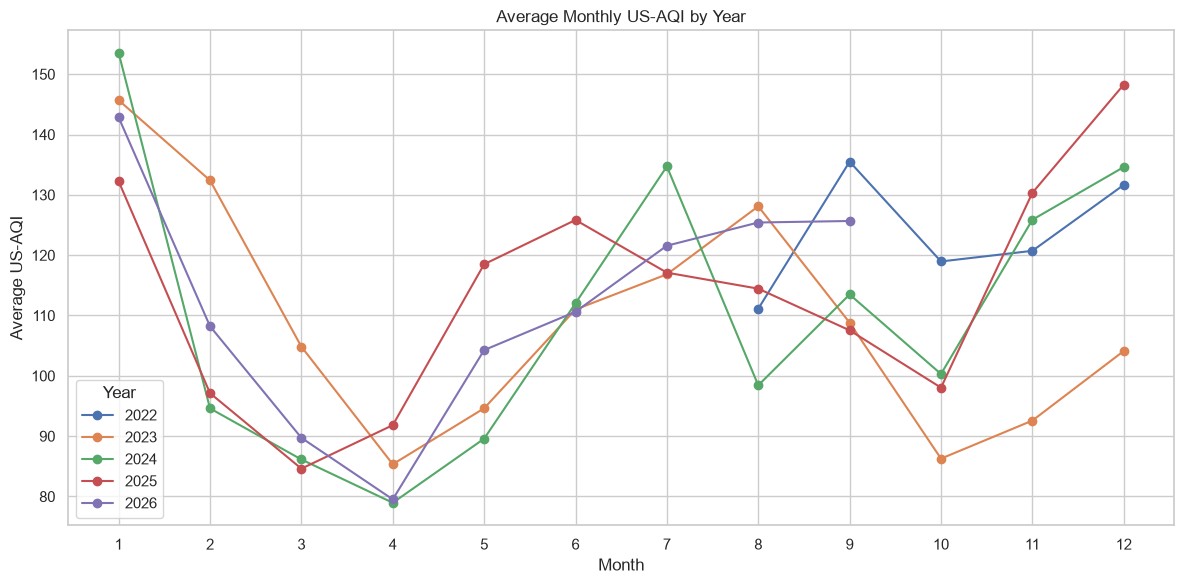

In [12]:
# Year-over-year comparison, to sanity check whether winters are consistently worse
yearly_monthly = df.groupby(["year", "month"])["us_aqi"].mean().unstack(level=0)

plt.figure(figsize=(12, 6))
for year in yearly_monthly.columns:
    plt.plot(yearly_monthly.index, yearly_monthly[year], marker="o", label=str(year))
plt.title("Average Monthly US-AQI by Year")
plt.xlabel("Month")
plt.ylabel("Average US-AQI")
plt.legend(title="Year")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## 6. Pollutant Correlations

Which pollutants move together, and which correlate most strongly with the overall AQI value?

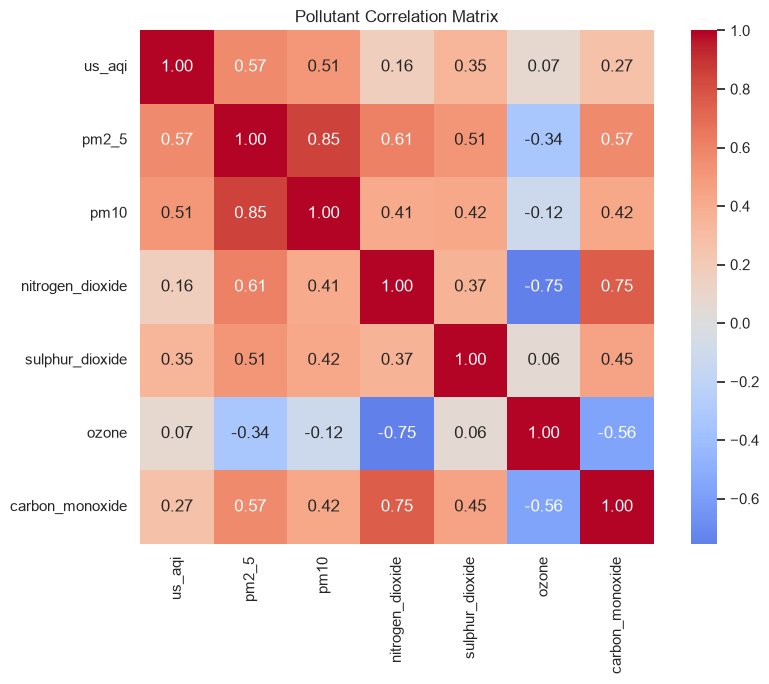

Correlation with us_aqi, sorted:
us_aqi              1.000000
pm2_5               0.568464
pm10                0.510680
sulphur_dioxide     0.345575
carbon_monoxide     0.269124
nitrogen_dioxide    0.164646
ozone               0.072446
Name: us_aqi, dtype: float64


In [13]:
pollutant_cols = ["us_aqi", "pm2_5", "pm10", "nitrogen_dioxide", "sulphur_dioxide", "ozone", "carbon_monoxide"]
available_cols = [c for c in pollutant_cols if c in df.columns]

corr = df[available_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Pollutant Correlation Matrix")
plt.tight_layout()
plt.show()

print("Correlation with us_aqi, sorted:")
print(corr["us_aqi"].sort_values(ascending=False))

## 7. Autocorrelation — How Predictable Is AQI From Its Own Past?

This directly informs the model's target horizons (24h/48h/72h): if autocorrelation decays quickly, longer horizons will inherently be harder to predict — which matches what we observed in model evaluation (24h R² ≈ 0.80, 72h R² ≈ 0.48).

In [15]:
!pip install statsmodels

  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 1.0 MB/s eta 0:00:11
   --- ------------------------------------ 1.0/11.3 MB 1.5 MB/s eta 0:00:07
   --- ------------------------------------ 1.0/11.3 MB 1.5 MB/s eta 0:00:07
   ----- ---------------------------------- 1.6/11.3 MB 1.5 MB/s eta 0:00:07
   -------- ------------------------------- 2.4/11.3 MB 1.8 MB/s eta 0:00:05
   ---------- ----------------------------- 2.9/11.3 MB 2.1 MB/s eta 0:00:05
   ------------- -------------------------- 3.9/11.3


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


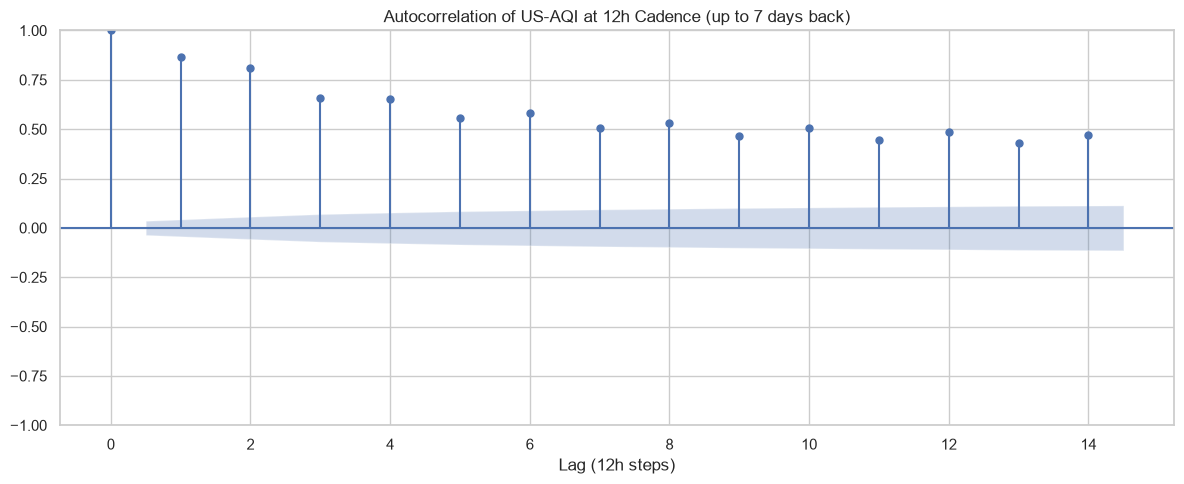

Correlation at key lags relevant to model targets:
  Lag 2  (24h ahead): 0.808
  Lag 4  (48h ahead): 0.652
  Lag 6  (72h ahead): 0.581


In [16]:
from statsmodels.graphics.tsaplots import plot_acf

# Resample to 12h to match the model's actual cadence before checking autocorrelation
df_12h = df.set_index("time")["us_aqi"].resample("12h").mean().interpolate()

fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(df_12h.dropna(), lags=14, ax=ax)  # 14 lags * 12h = 7 days
ax.set_title("Autocorrelation of US-AQI at 12h Cadence (up to 7 days back)")
ax.set_xlabel("Lag (12h steps)")
plt.tight_layout()
plt.show()

print("Correlation at key lags relevant to model targets:")
print(f"  Lag 2  (24h ahead): {df_12h.autocorr(lag=2):.3f}")
print(f"  Lag 4  (48h ahead): {df_12h.autocorr(lag=4):.3f}")
print(f"  Lag 6  (72h ahead): {df_12h.autocorr(lag=6):.3f}")

## 8. Summary of Findings

Fill in the actual numbers from the cells above once run, but the expected/observed pattern is:

1. **Coverage:** ~4 years of hourly data (Open-Meteo's practical archive limit for this location), aggregated to a 12-hour cadence for modeling → ~2,986 training rows.
2. **AQI distribution is heavily skewed toward Moderate / Unhealthy-for-Sensitive** (roughly 80%+ combined); Very Unhealthy is rare (~0.2%) and Hazardous does not occur in this dataset at all. This directly limits how well the model can be validated against extreme events, and is why the dashboard's hazardous-AQI alert logic is threshold-based rather than learned from examples.
3. **Seasonality is present:** winter months show visibly higher average AQI than summer months, consistent with known temperature-inversion and crop-burning effects in the region — this justifies including `month_sin`/`month_cos` cyclical features.
4. **PM2.5 and PM10 are the dominant drivers of `us_aqi`**, as expected from how the US-AQI index is constructed; NO2/SO2/CO contribute comparatively little in this dataset.
5. **Autocorrelation decays with lag**, which explains the systematic drop in model R² from 24h (≈ 0.80) to 72h (≈ 0.48) seen during training — this isn't a model deficiency so much as a property of the underlying signal: AQI 72 hours out is genuinely harder to predict from current conditions alone.

**Implication for the report:** the model's strong short-horizon performance and weaker long-horizon performance is expected and explainable from the data itself, not just a modeling shortfall — and the near-total absence of hazardous-range examples means alerting logic should be presented as threshold-based safety guidance, not as a validated prediction capability for extreme events.